<h3> 1. Covering the commodities classes energy and metals </h3>
<p> In this section we will be extracting each price return and extracting features that will help in the prediction of the energy and metals asset classes </p>


In [103]:
# Setting the imports

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, RocCurveDisplay)
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import shap

In [104]:
# Reading the orginal prices dataframe

prices_df = pd.read_csv('../data/src/ohlcv_data.csv')
prices_df['date'] = pd.to_datetime(prices_df['date'])
prices_df = prices_df.set_index('date')

# Reading the primary signal dataframe
primary_df = pd.read_csv('../data/src/primary_signals.csv')
primary_df['date'] = pd.to_datetime(primary_df['date'])
primary_df = primary_df.set_index('date')

# Extracting instrument wti
wti_df = prices_df.loc[prices_df['instrument'] == 'cl1s'].copy()
wti_primary_df =  primary_df[['cl1s']].copy()

# Extracting instrument Heating oil
heating_oil_df = prices_df.loc[prices_df['instrument'] == 'ho1s'].copy()
heating_oil_primary_df = primary_df.loc[:,'ho1s'].copy()

# Extracting RBOB gasoline
rbob_df = prices_df.loc[prices_df['instrument'] == 'rb1s'].copy()
rbob_primary_df = primary_df.loc[:,'rb1s'].copy()

# Extracting natural gas 
natural_gas_df = prices_df.loc[prices_df['instrument'] == 'ng1s'].copy()
natural_gas_primary_df = primary_df.loc[:,'ng1s'].copy()

# # Extracting gold
# gold_df = prices_df.loc[prices_df['instrument'] == 'gc1s'].copy()
# gold_primary_df = primary_df.loc[:,'gc1s'].copy()

# # Extracting silver
# silver_df = prices_df.loc[prices_df['instrument'] == 'si1s'].copy()
# silver_primary_df = primary_df.loc[:,'si1s'].copy()

# # Extracting copper
# copper_df = prices_df.loc[prices_df['instrument'] == 'hg1s'].copy()
# copper_primary_df = primary_df.loc[:,'hg1s'].copy()

# # Extracting platinimum 
# plat_df = prices_df.loc[prices_df['instrument'] == 'pl1s'].copy()
# plat_primary_df = primary_df.loc[:,'pl1s'].copy()

instruments = {
    'WTI': {'price_df': wti_df, 'signal': wti_primary_df},
    'Heating Oil': {'price_df': heating_oil_df, 'signal': heating_oil_primary_df},
    'RBOB Gasoline': {'price_df': rbob_df, 'signal': rbob_primary_df},
    'Natural Gas': {'price_df': natural_gas_df, 'signal': natural_gas_primary_df},
    # 'Gold': {'price_df': gold_df, 'signal': gold_primary_df},
    # 'Silver': {'price_df': silver_df, 'signal': silver_primary_df},
    # 'Copper': {'price_df': copper_df, 'signal': copper_primary_df},
    # 'Platinum': {'price_df': plat_df, 'signal': plat_primary_df},
}


### 2. Quick Data exploration plotting 
<p> Plotting each asset class for each instrument chosen </p>

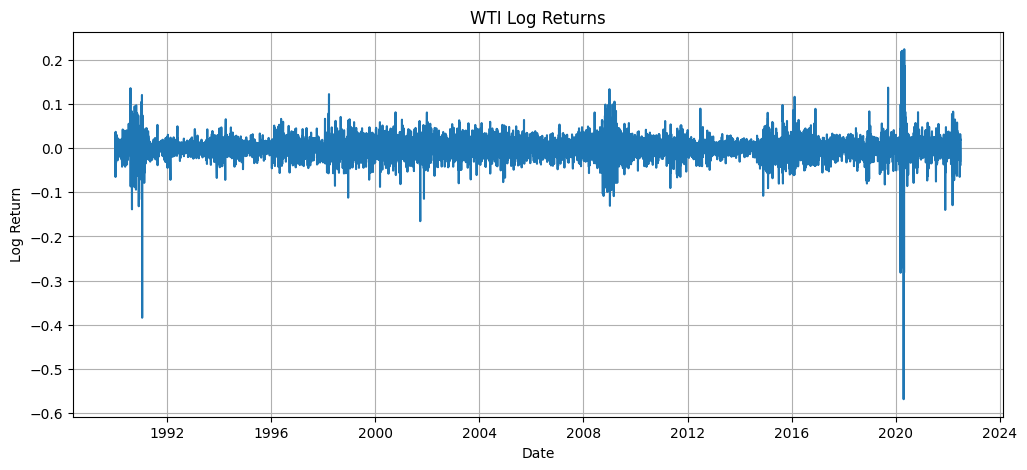

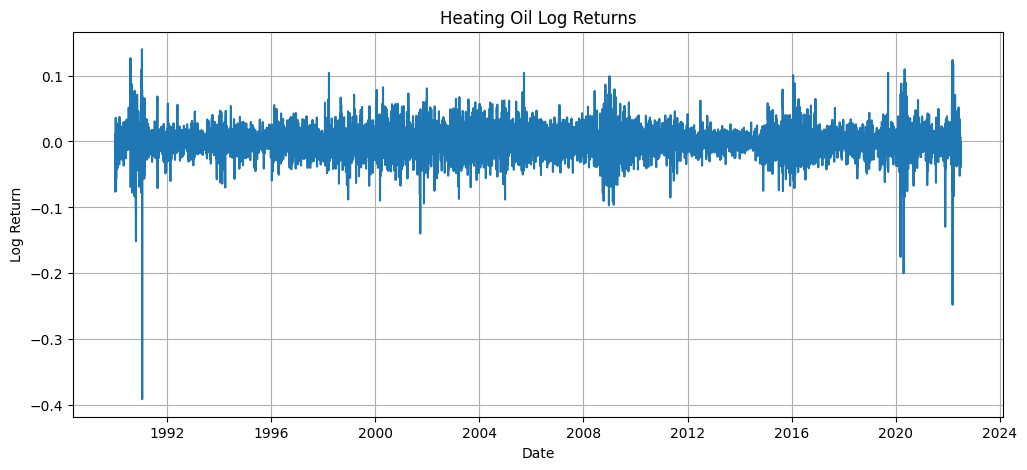

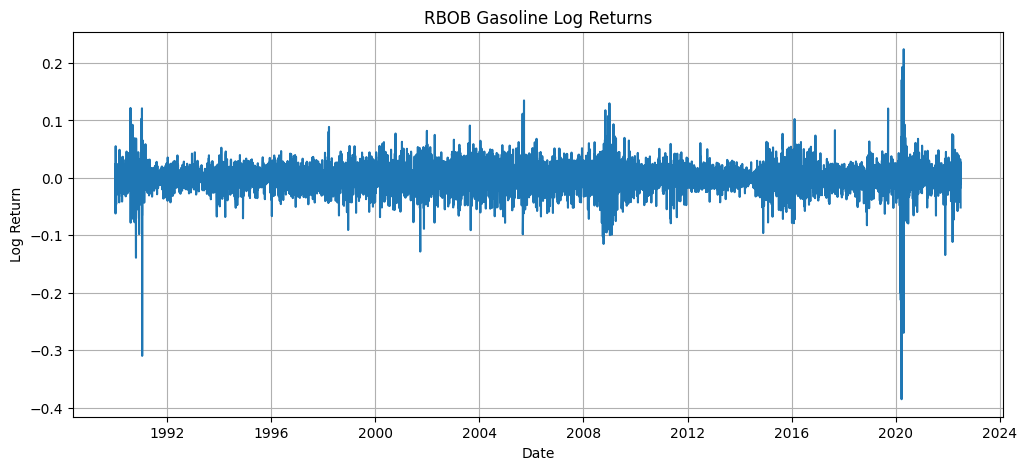

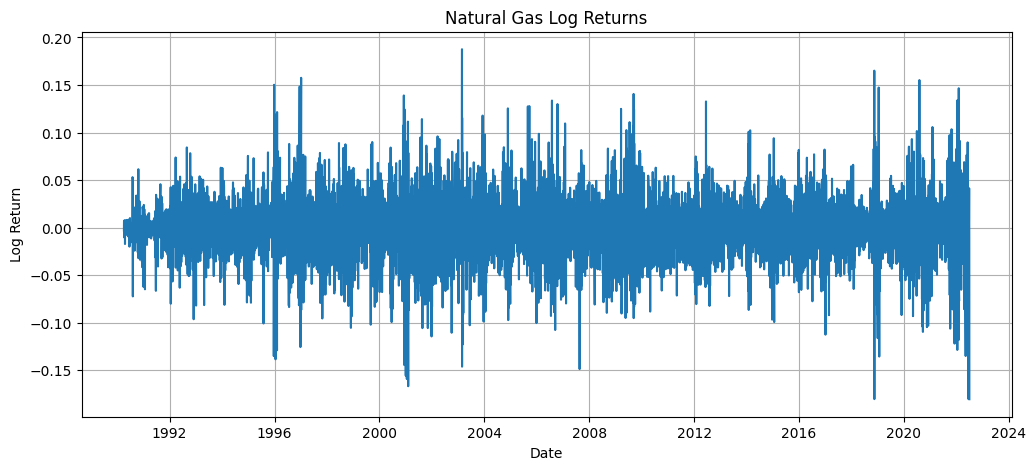

In [105]:
# Getting the returns in each case and plotting them

for instrument,dataframes in instruments.items():
    df = dataframes['price_df']
    df['returns'] = np.log(df['close']/df['close'].shift(1))
    # Plot
    plt.figure(figsize=(12, 5))

    plt.plot(
        df.index,
        df['returns']
    )

    plt.title(f'{instrument} Log Returns')
    plt.xlabel('Date')
    plt.ylabel('Log Return')

    plt.grid(True)

    plt.show()


<h3> 3. Feature engineering </h3>
<p> For each instrument we will be engineering some features, some common technical indicators, HMMs then we will cluster features using PCA then run EM to further cluster down common features </p>

<h4> 3.1 WTI feature engineering </h4>
<p> In this section we will build the features needed in building the meta model for the WTI </p>


In [106]:
# This section entails generic functions for technical indicators which can be used anywhere in the code

def rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    
    # Wilder's smoothing (exponential, not simple moving average)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))



In [107]:
wti_df_feat = wti_df.copy()

wti_df_feat['vol_20'] = wti_df_feat['returns'].rolling(20).std()
wti_df_feat['vol_60'] = wti_df_feat['returns'].rolling(60).std()
wti_df_feat['mom_20'] = wti_df_feat['close'].pct_change(20)
wti_df_feat['mom_60'] = wti_df_feat['close'].pct_change(60)
wti_df_feat['rsi_14'] = rsi(wti_df_feat['close'], 14)
wti_df_feat['rsi_21'] = rsi(wti_df_feat['close'], 21)

ovx_df = pd.read_csv('../data/src/ovx.csv')
ovx_df = ovx_df[['Date', 'Close']]
ovx_df['Date'] = pd.to_datetime(ovx_df['Date'])
ovx_df = ovx_df.set_index('Date')
ovx_df = ovx_df.rename(columns={'Close': 'ovx_close'})

wti_df_feat = pd.concat([wti_df_feat, ovx_df], axis=1)

# Fix 1: keep the formula on one line
wti_df_feat['ovx_z'] = (wti_df_feat['ovx_close'] - wti_df_feat['ovx_close'].rolling(63).mean()) / wti_df_feat['ovx_close'].rolling(63).std()

wti_df_feat['iv_rv_ratio'] = wti_df_feat['ovx_close'] / (wti_df_feat['close'].pct_change().rolling(21).std() * np.sqrt(252) * 100)
wti_df_feat['ovx_slope']   = wti_df_feat['ovx_close'].diff(5) / wti_df_feat['ovx_close'].shift(5)

wti_df_feat = wti_df_feat.dropna()

SIGNAL_START    = '2021-08-16'
features_to_use = ['ovx_z', 'iv_rv_ratio', 'ovx_slope', 'returns', 'vol_20', 'mom_20', 'rsi_14', 'rsi_21']

# Fix 2: use wti_df_feat.index, not wti_df.index
wti_train = wti_df_feat.loc[wti_df_feat.index < SIGNAL_START,  features_to_use].copy()
wti_test  = wti_df_feat.loc[wti_df_feat.index >= SIGNAL_START, features_to_use].copy()

train_mask = wti_train.notna().all(axis=1)
test_mask  = wti_test.notna().all(axis=1)

wti_train_clean = wti_train[train_mask]
wti_test_clean  = wti_test[test_mask]

scaler = StandardScaler()
X_train_scaled_wti = scaler.fit_transform(wti_train_clean)
X_test_scaled_wti  = scaler.transform(wti_test_clean)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled_wti)
X_test_pca  = pca.transform(X_test_scaled_wti)

pc_columns = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

train_pca_df_wti = pd.DataFrame(X_train_pca, index=wti_train_clean.index, columns=pc_columns)
test_pca_df_wti  = pd.DataFrame(X_test_pca,  index=wti_test_clean.index,  columns=pc_columns)

explained_variance = pd.DataFrame({
    'PC': pc_columns,
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_),
})
print(explained_variance)
print(f"\nNumber of PCs kept: {pca.n_components_}")


    PC  Explained Variance Ratio  Cumulative Variance
0  PC1                  0.422631             0.422631
1  PC2                  0.204758             0.627389
2  PC3                  0.115463             0.742852
3  PC4                  0.107801             0.850653
4  PC5                  0.060912             0.911565
5  PC6                  0.045672             0.957237

Number of PCs kept: 6


In [108]:

X_train_hmm = train_pca_df_wti.values
X_test_hmm = test_pca_df_wti.values

def hmm_bic(hmm_model, X):
    K = hmm_model.n_components
    T, d = X.shape
    logL = hmm_model.score(X)

    # For diag covariance:
    # start probs: K - 1
    # transition matrix: K * (K - 1)
    # means: K * d
    # variances: K * d
    k_params = (K - 1) + (K * (K - 1)) + K * (2 * d)

    bic = -2 * logL + k_params * np.log(T)
    return bic, logL

state_range = range(2, 8)

results = []
best = {
    "bic": np.inf,
    "hmm": None,
    "K": None,
    "logL": None
}

for K in state_range:
    best_for_K = {
        "bic": np.inf,
        "hmm": None,
        "logL": None
    }

    for seed in range(10):
        hmm = GaussianHMM(
            n_components=K,
            covariance_type="diag",
            n_iter=1000,
            random_state=42 + seed,
            verbose=False
        )

        hmm.fit(X_train_hmm)

        bic, logL = hmm_bic(hmm, X_train_hmm)

        if bic < best_for_K["bic"]:
            best_for_K = {
                "bic": bic,
                "hmm": hmm,
                "logL": logL
            }

    results.append((K, best_for_K["bic"], best_for_K["logL"]))

    if best_for_K["bic"] < best["bic"]:
        best = {
            "bic": best_for_K["bic"],
            "hmm": best_for_K["hmm"],
            "K": K,
            "logL": best_for_K["logL"]
        }

print("\nHMM BIC results:")
for K, bic, logL in results:
    print(f"K={K}: BIC={bic:,.1f}, logL={logL:,.1f}")

print(f"\nSelected K={best['K']} with BIC={best['bic']:,.1f}")

hmm_best = best["hmm"]

train_states = hmm_best.predict(X_train_hmm)
test_states = hmm_best.predict(X_test_hmm)

train_probs = hmm_best.predict_proba(X_train_hmm)
test_probs = hmm_best.predict_proba(X_test_hmm)





HMM BIC results:
K=2: BIC=46,235.0, logL=-23,008.8
K=3: BIC=43,039.1, logL=-21,342.5
K=4: BIC=40,694.3, logL=-20,093.6
K=5: BIC=39,047.9, logL=-19,185.9
K=6: BIC=38,258.4, logL=-18,698.6
K=7: BIC=37,503.2, logL=-18,220.4

Selected K=7 with BIC=37,503.2


In [109]:
# Add HMM probabilities to PCA train/test dataframes
for i in range(best["K"]):
    train_pca_df_wti[f'hmm_prob_{i}'] = train_probs[:, i]
    test_pca_df_wti[f'hmm_prob_{i}'] = test_probs[:, i]

In [110]:
wti_primary_df.head()

,cl1s
date,
2020-01-03,0
2020-01-06,0
2020-01-07,-1
2020-01-08,0
2020-01-09,0


<h3> Explanation of the triple barrier method </h3>
<p> Our triple barrier function 

In [111]:
# Cell 8 — replace with this

wti_df_temp = wti_df.copy()
wti_primary_df_temp = wti_primary_df.copy()

labeling_wti = wti_df_temp.join(wti_primary_df_temp, how='inner')

def get_daily_vol(close, span=20):
    log_ret = np.log(close).diff()
    return log_ret.ewm(span=span).std()

def triple_barrier_meta_labels(close, signals, pt_sl, max_hold):
    vol = get_daily_vol(close)
    out = []

    for t0, side in signals.items():
        # Skip neutral and NaN signals — when side=0, ret=0 always → PT/SL never hit
        if pd.isna(side) or side == 0:
            continue

        if t0 not in close.index or t0 not in vol.index:
            continue

        sigma = vol.loc[t0]
        if pd.isna(sigma) or sigma <= 0:
            continue

        pt =  pt_sl[0] * sigma
        sl = -pt_sl[1] * sigma

        idx   = close.index.searchsorted(t0)
        t1    = close.index[min(idx + max_hold, len(close.index) - 1)]

        entry_price = close.loc[t0]
        # Exclude the entry bar itself so ret starts from the next day
        future_prices = close.loc[t0:t1].iloc[1:]

        if future_prices.empty:
            continue

        ret = (future_prices / entry_price - 1) * side

        hit_pt = ret[ret >= pt].index.min()
        hit_sl = ret[ret <= sl].index.min()

        candidates = {k: v for k, v in {'pt': hit_pt, 'sl': hit_sl, 't1': t1}.items()
                      if pd.notna(v)}
        first_touch = min(candidates, key=candidates.get)

        out.append({
            'entry':          t0,
            'exit':           candidates[first_touch],
            'sigma_at_entry': sigma,
            'pt_width':       pt,
            'sl_width':       sl,
            'primary_signal': side,
            'first_touch':    first_touch,   # added: shows whether PT, SL, or T1
            'meta_label':     1 if first_touch == 'pt' else 0,
        })

    return pd.DataFrame(out).set_index('entry')


<h3> Max holding period and take profit choice </h3>
<p> For WTI the max holding period will be , since without the max holding period this would create unrealistic trades, as some trades might continue forever. Since our data is daily and WTI patterns tend to stay persistent for about a month then the holding period chosen would be 20 days holding. </p>

<p> For know when it comes to the take profit multiplier than that multiplier we will calibrated to be 1.5 since WTI's typical daily volatility is 2% if we multiply that by 1.5 we get a volatility of 3, since for crude oil barriers should be scaled by realized volatility having a fixed window will miss multiple trades and will not realize significant and real trades </p>

In [113]:
# In this code we will get the labels from the tripple barrier method and we will use the same holdout period mentioned in the above explanation
pt_sl = [1.5,1.5]
holdout_period = 20
wti_labels = triple_barrier_meta_labels(labeling_wti['close'], labeling_wti['cl1s'],pt_sl,holdout_period)


In [114]:
print(len(wti_primary_df))
len(wti_labels)

645


421

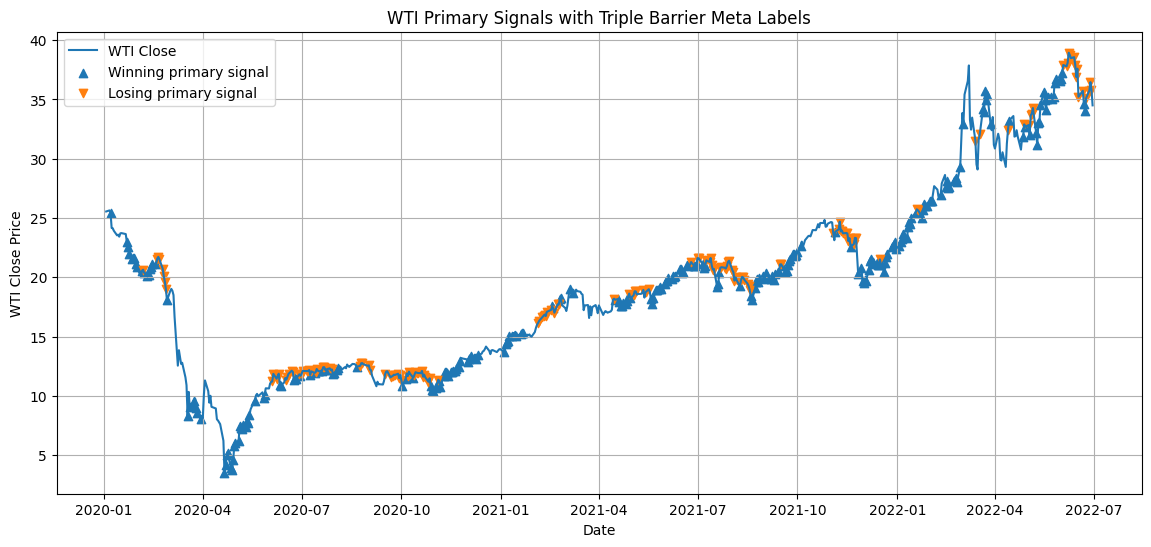

In [115]:
# In this code we are plotting the meta labels of WTI

plt.figure(figsize=(14, 6))

plt.plot(labeling_wti.index, labeling_wti['close'], label='WTI Close')

wins = wti_labels[wti_labels['meta_label'] == 1]
losses = wti_labels[wti_labels['meta_label'] == 0]

plt.scatter(
    wins.index,
    labeling_wti.loc[wins.index, 'close'],
    marker='^',
    label='Winning primary signal'
)

plt.scatter(
    losses.index,
    labeling_wti.loc[losses.index, 'close'],
    marker='v',
    label='Losing primary signal'
)

plt.title('WTI Primary Signals with Triple Barrier Meta Labels')
plt.xlabel('Date')
plt.ylabel('WTI Close Price')
plt.legend()
plt.grid(True)
plt.show()

In [120]:
# After generating the labels i want to split them in y_train and y_test 
y_train_wti = wti_labels[:SIGNAL_START]
y_test_wti = wti_labels[SIGNAL_START:]


In [122]:
# Stitiching together X_test_wti and X_train_wti

X_train_wti = train_pca_df_wti.reindex(y_train_wti.index).dropna()
X_test_wti  = test_pca_df_wti.reindex(y_test_wti.index).dropna()

# Align labels to the same rows (reindex may drop a few if features were NaN)
y_train_wti = y_train_wti.loc[X_train_wti.index, 'meta_label']
y_test_wti  = y_test_wti.loc[X_test_wti.index,  'meta_label']

print(X_train_wti.shape, y_train_wti.shape)
print(X_test_wti.shape,  y_test_wti.shape)


(259, 13) (259,)
(162, 13) (162,)
